In [2]:
import time
import random

def merge(arr, left, mid, right):
    L = arr[left:mid+1]
    R = arr[mid+1:right+1]

    i = j = 0
    k = left

    while i < len(L) and j < len(R):
        if L[i] <= R[j]:
            arr[k] = L[i]
            i += 1
        else:
            arr[k] = R[j]
            j += 1
        k += 1

    while i < len(L):
        arr[k] = L[i]
        i += 1
        k += 1

    while j < len(R):
        arr[k] = R[j]
        j += 1
        k += 1


def merge_sort(arr, left, right):
    if left < right:
        mid = (left + right) // 2
        merge_sort(arr, left, mid)
        merge_sort(arr, mid+1, right)
        merge(arr, left, mid, right)


arr = [random.randint(1, 1000) for _ in range(1000)]

start = time.time()
merge_sort(arr, 0, len(arr)-1)
end = time.time()

print("First 10 Sorted Elements:", arr[:10])
print("Execution Time:", end - start)

First 10 Sorted Elements: [2, 4, 5, 6, 11, 11, 13, 14, 15, 17]
Execution Time: 0.004536151885986328


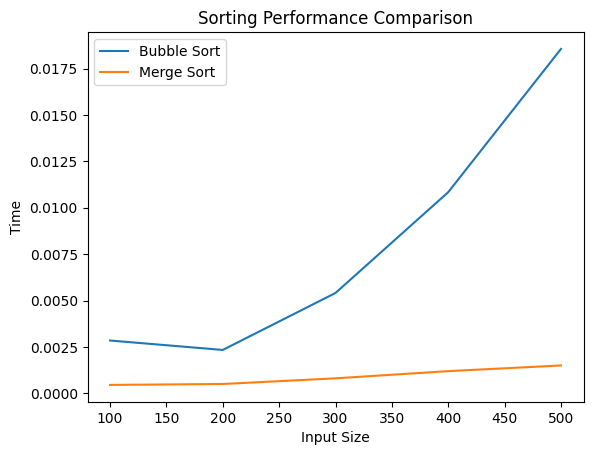

In [3]:
import matplotlib.pyplot as plt

def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]

sizes = [100, 200, 300, 400, 500]
bubble_times = []
merge_times = []

for n in sizes:
    arr1 = [random.randint(1, 1000) for _ in range(n)]
    arr2 = arr1.copy()

    start = time.time()
    bubble_sort(arr1)
    bubble_times.append(time.time() - start)

    start = time.time()
    merge_sort(arr2, 0, len(arr2)-1)
    merge_times.append(time.time() - start)

plt.plot(sizes, bubble_times, label="Bubble Sort")
plt.plot(sizes, merge_times, label="Merge Sort")
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.legend()
plt.title("Sorting Performance Comparison")
plt.show()

In [4]:
def activity_selection(start, end):
    activities = list(zip(start, end))
    activities.sort(key=lambda x: x[1])

    selected = [activities[0]]

    for i in range(1, len(activities)):
        if activities[i][0] >= selected[-1][1]:
            selected.append(activities[i])

    return selected

start = [1, 3, 0, 5, 8, 5]
end = [2, 4, 6, 7, 9, 9]

print("Selected Activities:", activity_selection(start, end))

Selected Activities: [(1, 2), (3, 4), (5, 7), (8, 9)]


In [5]:
def knapsack(W, wt, val, n):
    dp = [[0]*(W+1) for _ in range(n+1)]

    for i in range(1, n+1):
        for w in range(1, W+1):
            if wt[i-1] <= w:
                dp[i][w] = max(val[i-1] + dp[i-1][w-wt[i-1]],
                               dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]

    return dp[n][W]

wt = [1, 3, 4, 5]
val = [1, 4, 5, 7]
W = 7

print("Maximum Profit:", knapsack(W, wt, val, len(wt)))

Maximum Profit: 9


In [6]:
import itertools

def tsp(graph):
    n = len(graph)
    vertices = list(range(n))
    min_path = float('inf')

    for perm in itertools.permutations(vertices[1:]):
        current_weight = 0
        k = 0

        for j in perm:
            current_weight += graph[k][j]
            k = j

        current_weight += graph[k][0]
        min_path = min(min_path, current_weight)

    return min_path

graph = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

print("Minimum Cost:", tsp(graph))

Minimum Cost: 80
